# Cross-Validation and Model Selection

#### 🎯 Learning Goals

1. Understand the concepts of **Cross-Validation**.
2. Learn how to perform **Model Selection** using `sklearn`.

In [1]:
# Load our libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dsf_helpers as dsfh
from numpy.polynomial.legendre import legvander

# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

## Linear Regression with Cross-Validation

To predict crop yields, we'll deploy the `LinearRegression` model from `sklearn`. While we previously saw that higher degrees of polynomials led to overfitting, in this notebook, we will aim to select the optimal polynomial degree for our model using **Cross-Validation**.

Here's why Cross-Validation stands out:
- Employs the entirety of the dataset for both training and validation.
- Offers a more robust performance assessment, reflecting the model's capability to handle unseen data.

In essence, Cross-Validation provides a holistic view, ensuring we select our model using a comprehensive data evaluation instead of picking a model based on our training data's performance.

___

## Cross-Validation

Cross-validation is a resampling procedure employed to evaluate machine learning models on a limited data sample. Its primary purpose is to limit problems like overfitting, giving an insight into how the model will generalize to an independent dataset. It's essentially about leveraging different subsets of your data to train and validate the model, ensuring that it gets the opportunity to train on multiple train-validation splits. This offers multiple benefits, including a more robust model performance and a better understanding of the model's variance and bias.

### Leave-One-Out Cross-Validation (LOOCV)

Leave-One-Out Cross-Validation, often abbreviated as LOOCV, is a particular case of cross-validation where the $K$ (number of data splits) is set to the number of observations in the dataset. In LOOCV, the model is trained on all data points except one, which serves as the test set. This process is iteratively repeated until each data point has had a chance to be the validation set. However, LOOCV can be computationally expensive due to the number of times the model has to be retrained. It is, therefore, mostly practical for smaller datasets.

### K-Fold Cross-Validation

In K-Fold Cross-Validation, the dataset is randomly partitioned into $K$ equal-sized subsets (or folds). Of these, a single fold is retained as the validation set for model validation, while the remaining K-1 folds are used for training. This process is repeated K times, ensuring each fold gets a turn to serve as the validation set. The results from all $K$ validations are then averaged to produce a single estimation. K-Fold Cross-Validation is particularly beneficial when the dataset size is limited, as it ensures that every data point gets to be in both the training and validation sets, providing a more comprehensive view of the model's performance. Typically, values of $K$ like 5 or 10 are chosen, considering the balance between computational cost and the reliability of the performance estimation.


The `scikit-learn` documentation provides a great visual of cross-validation. The visual is shown below for a 5-fold cross-validation, but the intuition is the same for any value of $K$ (also $K=n$ for LOOCV):

![](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

In [2]:
# 🙀 🤯 Creates the orthogonal polynomial features

def poly(X, degree):
    """
    Stable polynomial features for teaching:
      - Map X to [-1, 1]
      - Legendre Vandermonde (degrees 0..degree)
      - Drop constant column
      - Standardize columns to unit variance (for comparability)
    """
    x = np.asarray(X).ravel()
    xmin, xmax = np.min(x), np.max(x)
    if xmax == xmin:
        z = np.zeros_like(x)
    else:
        z = 2.0 * (x - xmin) / (xmax - xmin) - 1.0

    V = legvander(z, degree)   # shape (n, degree+1)
    F = V[:, 1:]               # drop constant
    # column standardization (does not affect ridge predictions, but helps numerics)
    F = F - F.mean(axis=0)
    s = F.std(axis=0, ddof=0); s[s == 0] = 1.0
    F = F / s
    return F


In [3]:
# Begin by loading the data, the US crop yields data
crops = pd.read_csv("../data/us_crops.csv")

# Add the polynomial features directly to the DataFrame
max_degree = 50 # The maximum degree of the polynomial features
poly_features = poly(crops["temp"], max_degree)
for i in range(max_degree):
    crops[f"temp_{i+1}"] = poly_features[:, i]

crops.head()

,temp,yield,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,...,temp_41,temp_42,temp_43,temp_44,temp_45,temp_46,temp_47,temp_48,temp_49,temp_50
0,16.64,462.771538,0.854519,-0.382891,-1.031713,-0.565474,0.670270,0.984320,0.386415,-0.799514,...,0.019109,-0.720560,-0.599892,0.010586,0.624989,0.416869,-0.273064,-0.831303,-0.375185,0.329670
1,11.37,725.362676,-0.751456,-0.367518,1.345218,-0.592542,-0.633841,0.992066,-0.248593,-0.766739,...,-0.161273,-0.627050,0.635715,-0.174563,-0.713298,0.544447,0.110353,-0.797117,0.476152,0.155225
2,12.52,776.967318,-0.401006,-0.831581,1.052948,0.450802,-1.066740,0.014908,1.083391,-0.582170,...,0.654754,0.067507,-0.722303,0.078861,0.514331,-0.568393,-0.319555,0.562117,-0.034183,-0.723172
3,13.79,718.718013,-0.013988,-1.045221,0.309732,1.088460,-0.221455,-1.060273,0.386845,0.907904,...,-0.687254,-0.025638,0.654057,-0.240438,-0.755055,0.094718,0.658966,-0.312079,-0.675147,0.168581
4,11.97,533.642120,-0.568613,-0.641726,1.256633,-0.032619,-1.025682,0.615771,0.609306,-1.027110,...,-0.649523,0.416967,0.286136,-0.864865,0.091925,0.534884,-0.552136,-0.304517,0.673453,-0.354027


In [4]:
# Import the necessary tools from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [5]:
# Notice that temp_1 is not the same as temp, this is because we have orthogonalized the polynomials
X = crops.drop(columns=["temp", "yield"]) # Keep only the polynomial features
y = crops["yield"] # The yield is the target

# As before, we first split the data into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=25)

In `scikit-learn`, we can implement cross-validation using the `cross_val_score` function from the `model_selection` module. It takes the model, the entire dataset, and the number of folds as input. It returns the validation scores for each fold.

#### ➡️ ✏️ Task 1

Observe the code below, implementing cross-validation for a linear regression model with 5 folds. Why did we not use `.fit(X_train_subset, y_train)` to train the model?

In [6]:
# Create the 5-fold cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative

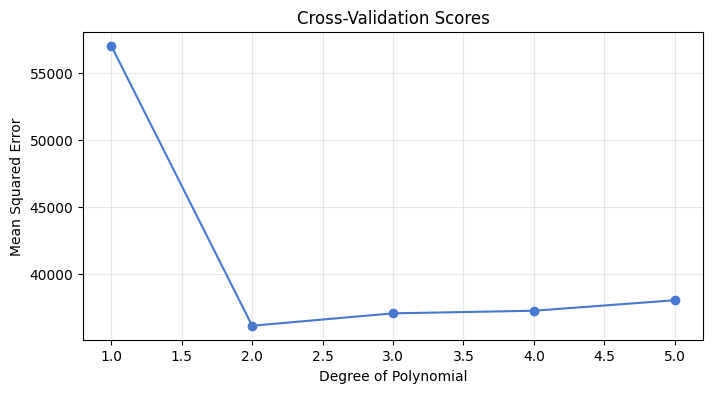

In [7]:
# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

In [8]:
print(f"Best degree of polynomial: {np.argmin(scores)+1}")

Best degree of polynomial: 2


#### ➡️ ✏️ Task 2

Repeat the above task but use $K=10$ and $K=n$ (LOOCV) folds. Do you notice any difference in the validation scores? What about in the speed of execution?

In [9]:
# ➡️ ✏️ Your code for 10-fold cross validation, including a plot

In [ ]:
# ➡️ ✏️ Your code for LOOCV, including a plot

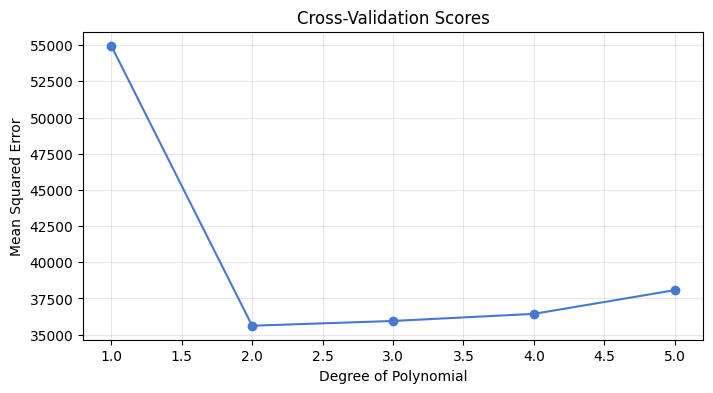

In [10]:
# SOLUTION for 10-fold CV
# Create the 10-fold cross-validation object
cv = KFold(n_splits=10, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative


# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

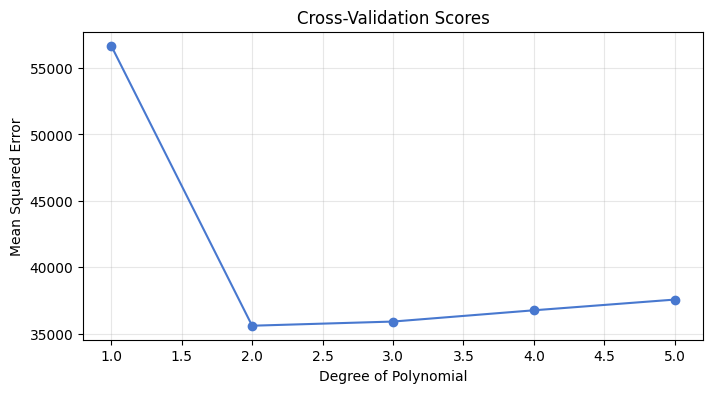

In [11]:
# SOLUTION for LOOCV
# Create the N-fold cross-validation object
cv = KFold(n_splits=X_train.shape[0], shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative


# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

___

## Diving Deeper: Cross-Validated Lasso and Ridge Regression

The bike rental dataset we've been analyzing offers a rich set of variables, and till now, we've merely skimmed its surface by focusing on a select subset: `temp`, `windspeed`, and `hum`.

### Why Expand Our Feature Set?
- **Information Utilization**: The unused columns might harbor critical insights and patterns that can significantly impact the accuracy of our predictions.
- **Complex Relationships**: While we started with basic features, more advanced features can capture intricate relationships, nonlinearities, and interactions that we might have missed.

### The Role of Lasso and Ridge Regression:
Regularization techniques, like Lasso and Ridge regression, shine when dealing with high-dimensional datasets:
- **Lasso: Feature Selection & Overfitting Control**: Lasso regression performs automatic feature selection. It adds a penalty that can shrink some coefficients all the way to zero, effectively removing the least relevant predictors. This helps us focus on the most important variables. Lasso penalizes the size of the coefficients as measured using the $L_1$ norm.
- **Ridge: Stabilization & Overfitting Control**: Ridge regression penalizes the size of the coefficients using the $L_2$ norm. This shrinks the coefficients toward zero but, unlike Lasso, never fully removes them. This makes the model more stable when predictors are highly correlated (multicollinear). Because Ridge spreads the influence across related variables instead of dropping some at random, Ridge often gives better prediction performance when many variables carry small, shared signals.

There is a further variety, **Elasitc Net**, that combines Lasso's feature selection with Ridge's stability. You may use it in your projects. 

### Cross-Validation: The Cornerstone of Reliable Model Assessment
- By integrating cross-validation, we ensure a thorough evaluation of our model's performance, mitigating the risk of coincidental high accuracies on a particular data split.
- Cross-validation gives us confidence in the stability and reliability of our model by testing it on various data partitions.

With the tools and techniques at our disposal, our objective is clear: harness the full potential of the dataset, employ advanced regularization techniques, and meticulously evaluate our model using cross-validation. The aim? Achieving a model performance that substantially outperforms our initial models, without spending hours on feature engineering. 


In [12]:
rentals = pd.read_csv("../data/bike_rental.csv")
rentals.head()

,season,y2012,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,0,0,0,0,0,0,1,1,0,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,0,0,0,0,0,0,1,1,0,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0


In [13]:
# Show the summary statistics of the rentals data
rentals.describe()

,season,y2012,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,...,0.143967,0.142643,0.141147,0.142413,0.142183,0.143104,0.144542,0.656712,0.261465,0.081823
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,...,0.351066,0.349719,0.348184,0.349484,0.349248,0.350189,0.351649,0.474820,0.439445,0.274103
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Observations on Variables

From our data statistics above:

1. **Scaling Discrepancies**:
    - Some variables are **not**:
        1. &hellip; within the range $[0, 1]$.
        2. &hellip; normalized with a mean of $0$ and a standard deviation of $1$.
    
2. **Categorical Variables**:
    - Some are categorical and do not imply order (e.g., `season`, the value $2$ is not *twice as much* as the value $1$).

These nuances can affect the behavior of linear models, especially when using regularization.

### The Importance of Normalization for Regularization

**Regularization** aims to prevent overfitting by penalizing large coefficients. It's crucial to remember how it works:
    
Suppose you're modeling a person's weight using their height. Two models are the same but one uses heigh in meters and the other in centimeters. Then the coefficients will differ substantially.

**Note**: The coefficient for height in centimeters would be much smaller than for height in meters (by a factor of $100$) – even though they represent the same height! E.g., it is not hard to show that 

$$\begin{align*}
\hat{f}(\mathbf{x}) &= \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{height\_in\_meters}\\
&= \hat{\beta}_0 + \hat{\beta}_1 \cdot \frac{\text{height\_in\_centimeters}}{100}\\
&= \hat{\beta}_0 + \frac{\hat{\beta}_1}{100} \cdot \text{height\_in\_centimeters}
\end{align*}$$

If we use regularization without normalization, the model might heavily penalize the `height_in_meters` variable just because of its scale, leading to a misleading model.

Using normalization, i.e., either scaling to $[0, 1]$ or standardizing to mean $0$ and standard deviation $1$, we rescale the two variables such that they are equal. Thus, regularization will treat them equally. **Don't forget to normalize your data!**

### Categorical Variables and Dummy Variables
Consider the season variable. If we use numbers like 1 for winter and 3 for summer, a linear model built as

$$\hat{f}(\mathbf{x}) = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{season}$$

will implicitly model the seasons using the same coefficient $\hat{\beta}_1$. Suppose that winter has a negative impact on bike rentals, while summer has a positive one. We would expect $\hat{\beta}_1$ to be negative. However, since summer is represented by the number 3, $\hat{\beta}_1$ will be three times larger than if we had used 1 for summer. This is not what we want!


Instead, we use dummy variables (or one-hot encoding):

+ `is_summer`: 1 for summer, 0 otherwise
+ `is_winter`: 1 for winter, 0 otherwise

This way, each season gets its own coefficient, and there's no implied order or magnitude difference between them.

$$\hat{f}(\mathbf{x}) = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{is\_winter} + \hat{\beta}_2 \cdot \text{is\_summer}$$
Remember: Data preprocessing can be as crucial as model selection!




In [14]:
# To create the one-hot encoded features, we may use the get_dummies function from pandas
pd.get_dummies(rentals, columns=["season", "weekday", "weathersit"])

,y2012,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,0,1,0,0,0,0.24,0.2879,0.81,0.0000,16,...,False,False,False,False,False,True,True,False,False,False
1,0,1,1,0,0,0.22,0.2727,0.80,0.0000,40,...,False,False,False,False,False,True,True,False,False,False
2,0,1,2,0,0,0.22,0.2727,0.80,0.0000,32,...,False,False,False,False,False,True,True,False,False,False
3,0,1,3,0,0,0.24,0.2879,0.75,0.0000,13,...,False,False,False,False,False,True,True,False,False,False
4,0,1,4,0,0,0.24,0.2879,0.75,0.0000,1,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,1,0.26,0.2576,0.60,0.1642,119,...,True,False,False,False,False,False,False,True,False,False
17375,1,12,20,0,1,0.26,0.2576,0.60,0.1642,89,...,True,False,False,False,False,False,False,True,False,False
17376,1,12,21,0,1,0.26,0.2576,0.60,0.1642,90,...,True,False,False,False,False,False,True,False,False,False
17377,1,12,22,0,1,0.26,0.2727,0.56,0.1343,61,...,True,False,False,False,False,False,True,False,False,False


In [15]:
# We no longer need the columns season, weekday and weathersit.
# Note that there are already dummies for hours (hr1, hr2, ... ) and months (mth1, mnth2, ...).
# Thus we can simply remove the original columns
rentals.drop(columns=["season", "weekday", "mnth", "hr", "weathersit"], 
            inplace=True)

In [16]:
rentals.describe()

,y2012,holiday,workingday,temp,atemp,hum,windspeed,cnt,spring,summer,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,0.028770,0.682721,0.496987,0.475775,0.627229,0.190098,189.463088,0.244088,0.253697,...,0.143967,0.142643,0.141147,0.142413,0.142183,0.143104,0.144542,0.656712,0.261465,0.081823
std,0.500008,0.167165,0.465431,0.192556,0.171850,0.192930,0.122340,181.387599,0.429557,0.435139,...,0.351066,0.349719,0.348184,0.349484,0.349248,0.350189,0.351649,0.474820,0.439445,0.274103
min,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.340000,0.333300,0.480000,0.104500,40.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.660000,0.621200,0.780000,0.253700,281.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.850700,977.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
# First, separate the data into features and target
X = rentals.drop(columns="cnt") # Keep all possible features
y = rentals["cnt"]

In [18]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72)

#### ➡️ ✏️ Task 3

1. Using `sklearn`'s `LinearRegression`, build a simple model that uses only the features `temp`, `windspeed`, and `hum` to predict the `cnt` column. Fit the model on the train set, we will use the test set later to compare the performance of this model with the model we will build using cross-validation.
2. Compute and compare the MSE of the model on the training and test sets.

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
# ➡️ ✏️ Your Code goes here

In [21]:
# SOLUTION
# ➡️ ✏️ Create a linear regression model and fit it on the training data
# using only temp, windspeed, and hum as features
linreg = LinearRegression().fit(X_train[["temp", "windspeed", "hum"]], y_train)


# ➡️ ✏️ Compute and compare the MSE of the model on the training and test sets.
mse_train_linreg = mean_squared_error(y_train, linreg.predict(X_train[["temp", "windspeed", "hum"]]))
mse_test_linreg = mean_squared_error(y_test, linreg.predict(X_test[["temp", "windspeed", "hum"]]))

print("Train MSE:", mse_train_linreg)
print("Test MSE:", mse_test_linreg)

Train MSE: 24822.36370607867
Test MSE: 24055.252122202703


In `scikit-learn`, the Lasso model comes directly with a cross-validation variant that performs cross-validation internally. The `LassoCV` class can be imported from the `linear_model` module. It takes the same parameters as its non-cross-validated counterpart, but it also takes an additional parameter `cv` that specifies the type of cross-validation to use. The `cv` parameter can be set to an integer, in which case the folds are created using `KFold` with the specified number of folds. There is also `RidgeCV`, but its functionality is somewhat more limited. More on this below.

This makes CV with Lasso very easy to implement. We can simply pass the entire dataset to the `LassoCV` class, and it will perform cross-validation internally. `LassoCV` also has a `cv_values_` attribute that contains the validation scores for each fold.

In [22]:
# Import the CV version of the Lasso
from sklearn.linear_model import LassoCV

In [23]:
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=72) # 5-fold CV

# Choosing which alphas we want to try out in the CV (optional)
alphas = np.logspace(-3, 3, 100) # Try out 100 alphas between 10^-3 and 10^3

In [24]:
X_train

,y2012,holiday,workingday,temp,atemp,hum,windspeed,spring,summer,fall,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
17139,1,0,1,0.26,0.2273,0.44,0.2985,1,0,0,...,0,0,0,0,0,1,0,1,0,0
1805,0,0,0,0.34,0.3030,0.53,0.3284,1,0,0,...,1,0,0,0,0,0,0,0,1,0
5326,0,0,0,0.70,0.6667,0.84,0.1642,0,0,1,...,1,0,0,0,0,0,0,1,0,0
12271,1,0,1,0.72,0.6515,0.37,0.1940,0,1,0,...,0,0,0,0,1,0,0,1,0,0
16537,1,0,1,0.34,0.3636,0.53,0.0000,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15567,1,0,1,0.52,0.5000,0.72,0.3881,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2885,0,0,1,0.34,0.3182,0.66,0.2537,0,1,0,...,0,0,0,0,1,0,0,1,0,0
7242,0,0,1,0.36,0.3485,0.81,0.1940,0,0,0,...,0,0,0,0,1,0,0,0,1,0
5166,0,0,1,0.66,0.5909,0.89,0.1045,0,0,1,...,0,1,0,0,0,0,0,1,0,0


In [25]:
# How many features do we have?
X_train.shape

(13034, 57)

In [26]:
lasso = LassoCV(alphas=alphas, cv=cv)
lasso_fit = lasso.fit(X_train, y_train)
lasso_fit

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=KFold(n_splits=5, random_state=72, shuffle=True))

In [27]:
# Get the entire array of MSEs for the folds for each alpha
lasso.mse_path_

array([[33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.

In [28]:
# Get the mean MSEs over the folds for each alpha
lasso.mse_path_.mean(axis=1)

array([32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32919.43802609,
       32451.67085026, 31747.52575669, 31035.12436163, 30496.23278446,
       29890.16576859, 27804.73577576, 25720.45340365, 23926.52230216,
       22166.16196572, 20694.41053057, 19020.56562953, 17476.38957021,
       16197.73222334, 15067.6806725 , 14097.06938854, 13362.83813742,
       12788.42600905, 12310.40495562, 11931.59664486, 11633.82842193,
       11403.70095358, 11209.30460244, 11040.97655111, 10906.43913816,
       10798.53670843, 10715.38205907, 10651.5717917 , 10603.17404101,
      

In [29]:
# And get the optimal alpha value
lasso.alpha_

np.float64(0.024770763559917114)

But what are the values of `alpha` (i.e., $\lambda$) that were used in the cross-validation tuning process? The `LassoCV` and `RidgeCV` classes have an `alpha_` attribute that contains the optimal value of `alpha` that was found during cross-validation.

Best regularization parameter: 0.02


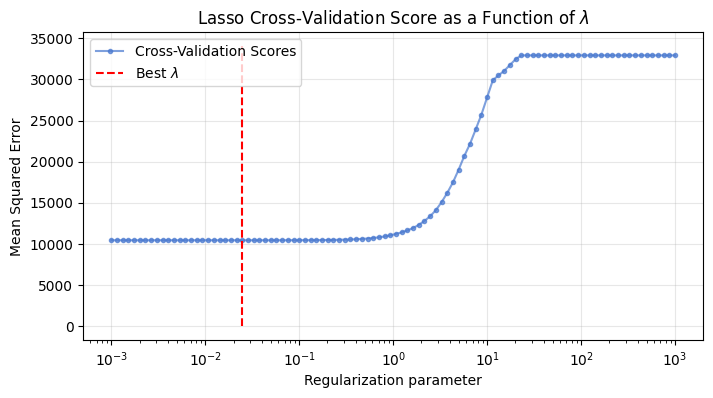

In [30]:
# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the CV MSE for each value of the regularization parameter that was tried
ax.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker="o", markersize=3,
        alpha=0.7, label="Cross-Validation Scores")
# Plot the final chosen regularization parameter
ax.vlines(lasso.alpha_, 0, ax.get_ylim()[1], linestyle="--", color="red", label=r"Best $\lambda$")

# Aesthetics
ax.set_xscale("log")
ax.set_xlabel("Regularization parameter")
ax.set_ylabel("Mean Squared Error")
ax.set_title(r"Lasso Cross-Validation Score as a Function of $\lambda$")
ax.grid(alpha=0.3)
ax.legend()

print(f"Best regularization parameter: {lasso.alpha_:.2f}")


#### ➡️ ✏️ Task 4: Ridge regression

**Note**: There exists `RidgeCV`, but it cannot be used to plot the values of $\lambda$ (or $\alpha$) and the matching cross-validation scores in the same way as with Lasso. You can, however, use the `Ridge` object and perform cross-validation yourself, like we did for the polynomial regression above. Go ahead and try it out! First import the Ridge object.

In [39]:
# ➡️ ✏️ Your code here

In [32]:
# SOLUTION
from sklearn.linear_model import Ridge

# Create the 5-fold cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each Ridge model)
ridge_scores = []

# Loop over the degrees of the polynomial
for alpha in alphas:
    
    ridge_model = Ridge(alpha=alpha)

    # Compute the cross-validation score and the mean squared error as the scoring function
    cv_score = cross_val_score( ridge_model, X_train, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    ridge_scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative

best_alpha_ridge = alphas[np.argmin( ridge_scores)]
best_score_ridge = np.min( ridge_scores)

np.float64(2.848035868435802)

np.float64(10441.602475391754)

Best regularization parameter: 2.85


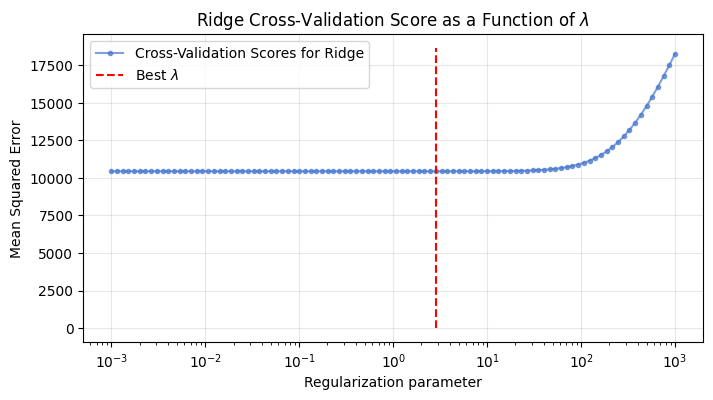

In [33]:
# SOLUTION (continued)
display(best_alpha_ridge)
display(best_score_ridge)

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the CV MSE for each value of the regularization parameter that was tried
ax.plot(alphas, ridge_scores, marker="o", markersize=3,
        alpha=0.7, label="Cross-Validation Scores for Ridge")
# Plot the final chosen regularization parameter
ax.vlines(best_alpha_ridge, 0, ax.get_ylim()[1], linestyle="--", color="red", label=r"Best $\lambda$")

# Aesthetics
ax.set_xscale("log")
ax.set_xlabel("Regularization parameter")
ax.set_ylabel("Mean Squared Error")
ax.set_title(r"Ridge Cross-Validation Score as a Function of $\lambda$")
ax.grid(alpha=0.3)
ax.legend()

print(f"Best regularization parameter: {best_alpha_ridge:.2f}")


#### ➡️ ✏️ Task 5

Write your own code to compare the predictions of the three models we have built so far. Which model performs the best?

In [34]:
# ➡️ ✏️ Your code here

In [35]:
# We already have the best model for LASSO, but still need to get it for ridge
mse_lasso_test = np.min(lasso.mse_path_.mean(axis=1))
mse_lasso_test, mse_test_linreg, best_score_ridge

(np.float64(10441.147906884897),
 np.float64(24055.252122202703),
 np.float64(10441.602475391754))

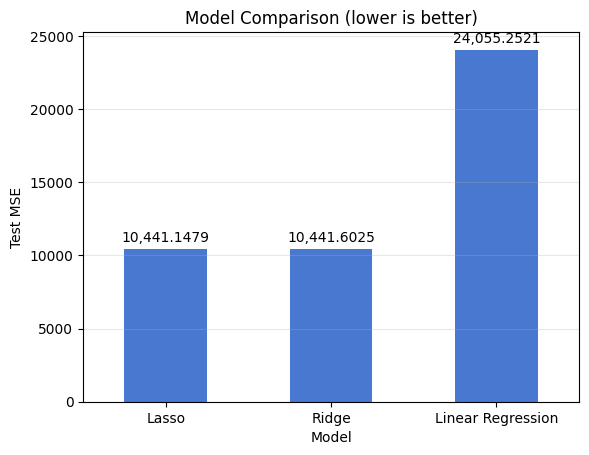

In [36]:
results = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Lasso", "Ridge"],
        "Test MSE": [mse_test_linreg, mse_lasso_test, best_score_ridge],
    }
).set_index("Model").sort_values("Test MSE")



# 2) Bar chart with value labels
ax = results.plot(kind="bar", legend=False, rot=0)
ax.set_ylabel("Test MSE")
ax.set_title("Model Comparison (lower is better)")
ax.grid(axis="y", alpha=0.3)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:,.4f}", (p.get_x() + p.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom")

# Here, for a change, you see a bar plot created in a coding style that's a little different
# from what we have done so far. Just to make you aware that there are many ways to create plots.
# Plot returns Matplotlib Axes. Bars are Rectangle "patches" stored in ax.patches.
# We loop over ax.patches to read each bar’s height (the MSE) and place a label at its center-top.
# get_x()/get_width() give the bar’s horizontal position; get_height() is the value.
# ax.annotate(..., xytext=(0,3), textcoords="offset points") nudges the text a few points above the bar edge.


# Cross-Validation and Model Selection

#### 🎯 Learning Goals

1. Understand the concepts of **Cross-Validation**.
2. Learn how to perform **Model Selection** using `sklearn`.

In [1]:
# Load our libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dsf_helpers as dsfh
from numpy.polynomial.legendre import legvander

# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

## Linear Regression with Cross-Validation

To predict crop yields, we'll deploy the `LinearRegression` model from `sklearn`. While we previously saw that higher degrees of polynomials led to overfitting, in this notebook, we will aim to select the optimal polynomial degree for our model using **Cross-Validation**.

Here's why Cross-Validation stands out:
- Employs the entirety of the dataset for both training and validation.
- Offers a more robust performance assessment, reflecting the model's capability to handle unseen data.

In essence, Cross-Validation provides a holistic view, ensuring we select our model using a comprehensive data evaluation instead of picking a model based on our training data's performance.

___

## Cross-Validation

Cross-validation is a resampling procedure employed to evaluate machine learning models on a limited data sample. Its primary purpose is to limit problems like overfitting, giving an insight into how the model will generalize to an independent dataset. It's essentially about leveraging different subsets of your data to train and validate the model, ensuring that it gets the opportunity to train on multiple train-validation splits. This offers multiple benefits, including a more robust model performance and a better understanding of the model's variance and bias.

### Leave-One-Out Cross-Validation (LOOCV)

Leave-One-Out Cross-Validation, often abbreviated as LOOCV, is a particular case of cross-validation where the $K$ (number of data splits) is set to the number of observations in the dataset. In LOOCV, the model is trained on all data points except one, which serves as the test set. This process is iteratively repeated until each data point has had a chance to be the validation set. However, LOOCV can be computationally expensive due to the number of times the model has to be retrained. It is, therefore, mostly practical for smaller datasets.

### K-Fold Cross-Validation

In K-Fold Cross-Validation, the dataset is randomly partitioned into $K$ equal-sized subsets (or folds). Of these, a single fold is retained as the validation set for model validation, while the remaining K-1 folds are used for training. This process is repeated K times, ensuring each fold gets a turn to serve as the validation set. The results from all $K$ validations are then averaged to produce a single estimation. K-Fold Cross-Validation is particularly beneficial when the dataset size is limited, as it ensures that every data point gets to be in both the training and validation sets, providing a more comprehensive view of the model's performance. Typically, values of $K$ like 5 or 10 are chosen, considering the balance between computational cost and the reliability of the performance estimation.


The `scikit-learn` documentation provides a great visual of cross-validation. The visual is shown below for a 5-fold cross-validation, but the intuition is the same for any value of $K$ (also $K=n$ for LOOCV):

![](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

In [2]:
# 🙀 🤯 Creates the orthogonal polynomial features

def poly(X, degree):
    """
    Stable polynomial features for teaching:
      - Map X to [-1, 1]
      - Legendre Vandermonde (degrees 0..degree)
      - Drop constant column
      - Standardize columns to unit variance (for comparability)
    """
    x = np.asarray(X).ravel()
    xmin, xmax = np.min(x), np.max(x)
    if xmax == xmin:
        z = np.zeros_like(x)
    else:
        z = 2.0 * (x - xmin) / (xmax - xmin) - 1.0

    V = legvander(z, degree)   # shape (n, degree+1)
    F = V[:, 1:]               # drop constant
    # column standardization (does not affect ridge predictions, but helps numerics)
    F = F - F.mean(axis=0)
    s = F.std(axis=0, ddof=0); s[s == 0] = 1.0
    F = F / s
    return F


In [3]:
# Begin by loading the data, the US crop yields data
crops = pd.read_csv("../data/us_crops.csv")

# Add the polynomial features directly to the DataFrame
max_degree = 50 # The maximum degree of the polynomial features
poly_features = poly(crops["temp"], max_degree)
for i in range(max_degree):
    crops[f"temp_{i+1}"] = poly_features[:, i]

crops.head()

,temp,yield,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,...,temp_41,temp_42,temp_43,temp_44,temp_45,temp_46,temp_47,temp_48,temp_49,temp_50
0,16.64,462.771538,0.854519,-0.382891,-1.031713,-0.565474,0.670270,0.984320,0.386415,-0.799514,...,0.019109,-0.720560,-0.599892,0.010586,0.624989,0.416869,-0.273064,-0.831303,-0.375185,0.329670
1,11.37,725.362676,-0.751456,-0.367518,1.345218,-0.592542,-0.633841,0.992066,-0.248593,-0.766739,...,-0.161273,-0.627050,0.635715,-0.174563,-0.713298,0.544447,0.110353,-0.797117,0.476152,0.155225
2,12.52,776.967318,-0.401006,-0.831581,1.052948,0.450802,-1.066740,0.014908,1.083391,-0.582170,...,0.654754,0.067507,-0.722303,0.078861,0.514331,-0.568393,-0.319555,0.562117,-0.034183,-0.723172
3,13.79,718.718013,-0.013988,-1.045221,0.309732,1.088460,-0.221455,-1.060273,0.386845,0.907904,...,-0.687254,-0.025638,0.654057,-0.240438,-0.755055,0.094718,0.658966,-0.312079,-0.675147,0.168581
4,11.97,533.642120,-0.568613,-0.641726,1.256633,-0.032619,-1.025682,0.615771,0.609306,-1.027110,...,-0.649523,0.416967,0.286136,-0.864865,0.091925,0.534884,-0.552136,-0.304517,0.673453,-0.354027


In [4]:
# Import the necessary tools from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [5]:
# Notice that temp_1 is not the same as temp, this is because we have orthogonalized the polynomials
X = crops.drop(columns=["temp", "yield"]) # Keep only the polynomial features
y = crops["yield"] # The yield is the target

# As before, we first split the data into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=25)

In `scikit-learn`, we can implement cross-validation using the `cross_val_score` function from the `model_selection` module. It takes the model, the entire dataset, and the number of folds as input. It returns the validation scores for each fold.

#### ➡️ ✏️ Task 1

Observe the code below, implementing cross-validation for a linear regression model with 5 folds. Why did we not use `.fit(X_train_subset, y_train)` to train the model?

In [6]:
# Create the 5-fold cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative

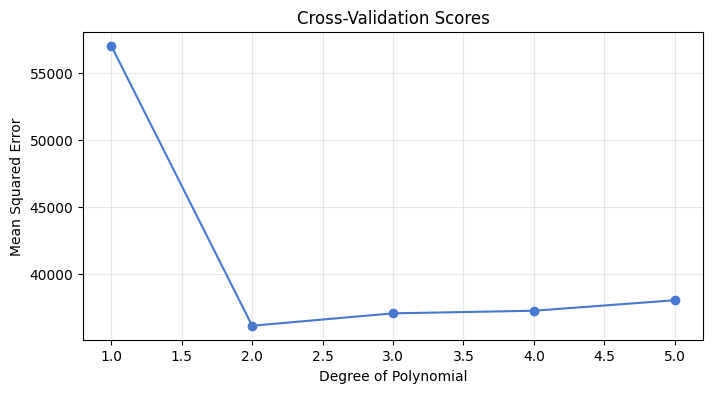

In [7]:
# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

In [8]:
print(f"Best degree of polynomial: {np.argmin(scores)+1}")

Best degree of polynomial: 2


#### ➡️ ✏️ Task 2

Repeat the above task but use $K=10$ and $K=n$ (LOOCV) folds. Do you notice any difference in the validation scores? What about in the speed of execution?

In [9]:
# ➡️ ✏️ Your code for 10-fold cross validation, including a plot

In [ ]:
# ➡️ ✏️ Your code for LOOCV, including a plot

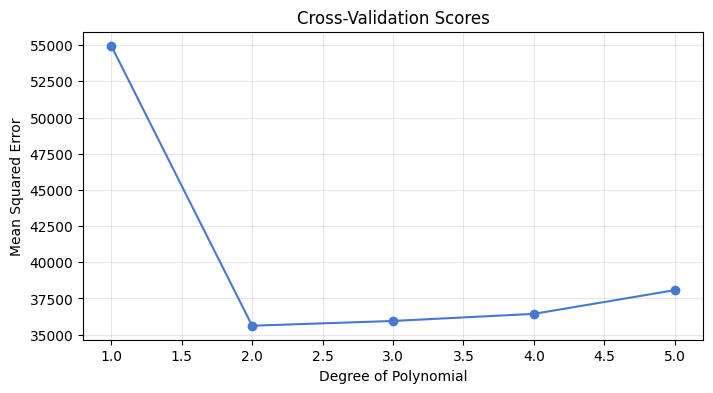

In [10]:
# SOLUTION for 10-fold CV
# Create the 10-fold cross-validation object
cv = KFold(n_splits=10, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative


# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

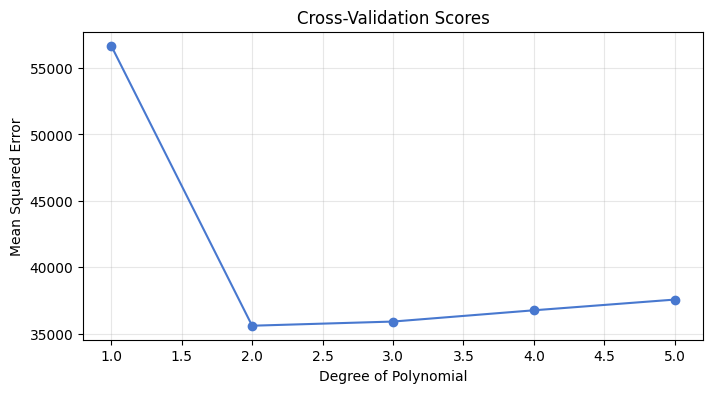

In [11]:
# SOLUTION for LOOCV
# Create the N-fold cross-validation object
cv = KFold(n_splits=X_train.shape[0], shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each degree of Polynomial)
scores = []

# Loop over the degrees of the polynomial
for degree in range(1, max_degree+1):
    # Subset the training data to keep only the polynomial features up to the current degree
    X_train_subset = X_train.loc[:, X_train.columns[:degree]]

    # Initialize the model
    model = LinearRegression()

    # Compute the cross-validation score using the current degree of the polynomial
    # and the mean squared error as the scoring function
    cv_score = cross_val_score(model, X_train_subset, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative


# Plot the scores as a function of the degree of the polynomial
fig, ax = plt.subplots(figsize=(8, 4))

plot_degree = 5 # Degree up to which we plot the scores (the rest has too high MSE)

ax.plot(range(1, plot_degree+1), scores[:plot_degree], marker="o")
ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Cross-Validation Scores")
ax.grid(alpha=.3)

___

## Diving Deeper: Cross-Validated Lasso and Ridge Regression

The bike rental dataset we've been analyzing offers a rich set of variables, and till now, we've merely skimmed its surface by focusing on a select subset: `temp`, `windspeed`, and `hum`.

### Why Expand Our Feature Set?
- **Information Utilization**: The unused columns might harbor critical insights and patterns that can significantly impact the accuracy of our predictions.
- **Complex Relationships**: While we started with basic features, more advanced features can capture intricate relationships, nonlinearities, and interactions that we might have missed.

### The Role of Lasso and Ridge Regression:
Regularization techniques, like Lasso and Ridge regression, shine when dealing with high-dimensional datasets:
- **Lasso: Feature Selection & Overfitting Control**: Lasso regression performs automatic feature selection. It adds a penalty that can shrink some coefficients all the way to zero, effectively removing the least relevant predictors. This helps us focus on the most important variables. Lasso penalizes the size of the coefficients as measured using the $L_1$ norm.
- **Ridge: Stabilization & Overfitting Control**: Ridge regression penalizes the size of the coefficients using the $L_2$ norm. This shrinks the coefficients toward zero but, unlike Lasso, never fully removes them. This makes the model more stable when predictors are highly correlated (multicollinear). Because Ridge spreads the influence across related variables instead of dropping some at random, Ridge often gives better prediction performance when many variables carry small, shared signals.

There is a further variety, **Elasitc Net**, that combines Lasso's feature selection with Ridge's stability. You may use it in your projects. 

### Cross-Validation: The Cornerstone of Reliable Model Assessment
- By integrating cross-validation, we ensure a thorough evaluation of our model's performance, mitigating the risk of coincidental high accuracies on a particular data split.
- Cross-validation gives us confidence in the stability and reliability of our model by testing it on various data partitions.

With the tools and techniques at our disposal, our objective is clear: harness the full potential of the dataset, employ advanced regularization techniques, and meticulously evaluate our model using cross-validation. The aim? Achieving a model performance that substantially outperforms our initial models, without spending hours on feature engineering. 


In [12]:
rentals = pd.read_csv("../data/bike_rental.csv")
rentals.head()

,season,y2012,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,0,0,0,0,0,0,1,1,0,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,0,0,0,0,0,0,1,1,0,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,0,0,0,0,0,0,1,1,0,0


In [13]:
# Show the summary statistics of the rentals data
rentals.describe()

,season,y2012,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,...,0.143967,0.142643,0.141147,0.142413,0.142183,0.143104,0.144542,0.656712,0.261465,0.081823
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,...,0.351066,0.349719,0.348184,0.349484,0.349248,0.350189,0.351649,0.474820,0.439445,0.274103
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Observations on Variables

From our data statistics above:

1. **Scaling Discrepancies**:
    - Some variables are **not**:
        1. &hellip; within the range $[0, 1]$.
        2. &hellip; normalized with a mean of $0$ and a standard deviation of $1$.
    
2. **Categorical Variables**:
    - Some are categorical and do not imply order (e.g., `season`, the value $2$ is not *twice as much* as the value $1$).

These nuances can affect the behavior of linear models, especially when using regularization.

### The Importance of Normalization for Regularization

**Regularization** aims to prevent overfitting by penalizing large coefficients. It's crucial to remember how it works:
    
Suppose you're modeling a person's weight using their height. Two models are the same but one uses heigh in meters and the other in centimeters. Then the coefficients will differ substantially.

**Note**: The coefficient for height in centimeters would be much smaller than for height in meters (by a factor of $100$) – even though they represent the same height! E.g., it is not hard to show that 

$$\begin{align*}
\hat{f}(\mathbf{x}) &= \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{height\_in\_meters}\\
&= \hat{\beta}_0 + \hat{\beta}_1 \cdot \frac{\text{height\_in\_centimeters}}{100}\\
&= \hat{\beta}_0 + \frac{\hat{\beta}_1}{100} \cdot \text{height\_in\_centimeters}
\end{align*}$$

If we use regularization without normalization, the model might heavily penalize the `height_in_meters` variable just because of its scale, leading to a misleading model.

Using normalization, i.e., either scaling to $[0, 1]$ or standardizing to mean $0$ and standard deviation $1$, we rescale the two variables such that they are equal. Thus, regularization will treat them equally. **Don't forget to normalize your data!**

### Categorical Variables and Dummy Variables
Consider the season variable. If we use numbers like 1 for winter and 3 for summer, a linear model built as

$$\hat{f}(\mathbf{x}) = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{season}$$

will implicitly model the seasons using the same coefficient $\hat{\beta}_1$. Suppose that winter has a negative impact on bike rentals, while summer has a positive one. We would expect $\hat{\beta}_1$ to be negative. However, since summer is represented by the number 3, $\hat{\beta}_1$ will be three times larger than if we had used 1 for summer. This is not what we want!


Instead, we use dummy variables (or one-hot encoding):

+ `is_summer`: 1 for summer, 0 otherwise
+ `is_winter`: 1 for winter, 0 otherwise

This way, each season gets its own coefficient, and there's no implied order or magnitude difference between them.

$$\hat{f}(\mathbf{x}) = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{is\_winter} + \hat{\beta}_2 \cdot \text{is\_summer}$$
Remember: Data preprocessing can be as crucial as model selection!




In [14]:
# To create the one-hot encoded features, we may use the get_dummies function from pandas
pd.get_dummies(rentals, columns=["season", "weekday", "weathersit"])

,y2012,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,0,1,0,0,0,0.24,0.2879,0.81,0.0000,16,...,False,False,False,False,False,True,True,False,False,False
1,0,1,1,0,0,0.22,0.2727,0.80,0.0000,40,...,False,False,False,False,False,True,True,False,False,False
2,0,1,2,0,0,0.22,0.2727,0.80,0.0000,32,...,False,False,False,False,False,True,True,False,False,False
3,0,1,3,0,0,0.24,0.2879,0.75,0.0000,13,...,False,False,False,False,False,True,True,False,False,False
4,0,1,4,0,0,0.24,0.2879,0.75,0.0000,1,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,1,0.26,0.2576,0.60,0.1642,119,...,True,False,False,False,False,False,False,True,False,False
17375,1,12,20,0,1,0.26,0.2576,0.60,0.1642,89,...,True,False,False,False,False,False,False,True,False,False
17376,1,12,21,0,1,0.26,0.2576,0.60,0.1642,90,...,True,False,False,False,False,False,True,False,False,False
17377,1,12,22,0,1,0.26,0.2727,0.56,0.1343,61,...,True,False,False,False,False,False,True,False,False,False


In [15]:
# We no longer need the columns season, weekday and weathersit.
# Note that there are already dummies for hours (hr1, hr2, ... ) and months (mth1, mnth2, ...).
# Thus we can simply remove the original columns
rentals.drop(columns=["season", "weekday", "mnth", "hr", "weathersit"], 
            inplace=True)

In [16]:
rentals.describe()

,y2012,holiday,workingday,temp,atemp,hum,windspeed,cnt,spring,summer,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,0.028770,0.682721,0.496987,0.475775,0.627229,0.190098,189.463088,0.244088,0.253697,...,0.143967,0.142643,0.141147,0.142413,0.142183,0.143104,0.144542,0.656712,0.261465,0.081823
std,0.500008,0.167165,0.465431,0.192556,0.171850,0.192930,0.122340,181.387599,0.429557,0.435139,...,0.351066,0.349719,0.348184,0.349484,0.349248,0.350189,0.351649,0.474820,0.439445,0.274103
min,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.340000,0.333300,0.480000,0.104500,40.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.660000,0.621200,0.780000,0.253700,281.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.850700,977.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
# First, separate the data into features and target
X = rentals.drop(columns="cnt") # Keep all possible features
y = rentals["cnt"]

In [18]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72)

#### ➡️ ✏️ Task 3

1. Using `sklearn`'s `LinearRegression`, build a simple model that uses only the features `temp`, `windspeed`, and `hum` to predict the `cnt` column. Fit the model on the train set, we will use the test set later to compare the performance of this model with the model we will build using cross-validation.
2. Compute and compare the MSE of the model on the training and test sets.

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
# ➡️ ✏️ Your Code goes here

In [21]:
# SOLUTION
# ➡️ ✏️ Create a linear regression model and fit it on the training data
# using only temp, windspeed, and hum as features
linreg = LinearRegression().fit(X_train[["temp", "windspeed", "hum"]], y_train)


# ➡️ ✏️ Compute and compare the MSE of the model on the training and test sets.
mse_train_linreg = mean_squared_error(y_train, linreg.predict(X_train[["temp", "windspeed", "hum"]]))
mse_test_linreg = mean_squared_error(y_test, linreg.predict(X_test[["temp", "windspeed", "hum"]]))

print("Train MSE:", mse_train_linreg)
print("Test MSE:", mse_test_linreg)

Train MSE: 24822.36370607867
Test MSE: 24055.252122202703


In `scikit-learn`, the Lasso model comes directly with a cross-validation variant that performs cross-validation internally. The `LassoCV` class can be imported from the `linear_model` module. It takes the same parameters as its non-cross-validated counterpart, but it also takes an additional parameter `cv` that specifies the type of cross-validation to use. The `cv` parameter can be set to an integer, in which case the folds are created using `KFold` with the specified number of folds. There is also `RidgeCV`, but its functionality is somewhat more limited. More on this below.

This makes CV with Lasso very easy to implement. We can simply pass the entire dataset to the `LassoCV` class, and it will perform cross-validation internally. `LassoCV` also has a `cv_values_` attribute that contains the validation scores for each fold.

In [22]:
# Import the CV version of the Lasso
from sklearn.linear_model import LassoCV

In [23]:
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=72) # 5-fold CV

# Choosing which alphas we want to try out in the CV (optional)
alphas = np.logspace(-3, 3, 100) # Try out 100 alphas between 10^-3 and 10^3

In [24]:
X_train

,y2012,holiday,workingday,temp,atemp,hum,windspeed,spring,summer,fall,...,weekday0,weekday1,weekday2,weekday3,weekday4,weekday5,weekday6,weathersit1,weathersit2,weathersit34
17139,1,0,1,0.26,0.2273,0.44,0.2985,1,0,0,...,0,0,0,0,0,1,0,1,0,0
1805,0,0,0,0.34,0.3030,0.53,0.3284,1,0,0,...,1,0,0,0,0,0,0,0,1,0
5326,0,0,0,0.70,0.6667,0.84,0.1642,0,0,1,...,1,0,0,0,0,0,0,1,0,0
12271,1,0,1,0.72,0.6515,0.37,0.1940,0,1,0,...,0,0,0,0,1,0,0,1,0,0
16537,1,0,1,0.34,0.3636,0.53,0.0000,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15567,1,0,1,0.52,0.5000,0.72,0.3881,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2885,0,0,1,0.34,0.3182,0.66,0.2537,0,1,0,...,0,0,0,0,1,0,0,1,0,0
7242,0,0,1,0.36,0.3485,0.81,0.1940,0,0,0,...,0,0,0,0,1,0,0,0,1,0
5166,0,0,1,0.66,0.5909,0.89,0.1045,0,0,1,...,0,1,0,0,0,0,0,1,0,0


In [25]:
# How many features do we have?
X_train.shape

(13034, 57)

In [26]:
lasso = LassoCV(alphas=alphas, cv=cv)
lasso_fit = lasso.fit(X_train, y_train)
lasso_fit

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=KFold(n_splits=5, random_state=72, shuffle=True))

In [27]:
# Get the entire array of MSEs for the folds for each alpha
lasso.mse_path_

array([[33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.52399868, 32300.94281015, 32889.77991758,
        33808.68801948],
       [33325.37730841, 32305.

In [28]:
# Get the mean MSEs over the folds for each alpha
lasso.mse_path_.mean(axis=1)

array([32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32926.06241086,
       32926.06241086, 32926.06241086, 32926.06241086, 32919.43802609,
       32451.67085026, 31747.52575669, 31035.12436163, 30496.23278446,
       29890.16576859, 27804.73577576, 25720.45340365, 23926.52230216,
       22166.16196572, 20694.41053057, 19020.56562953, 17476.38957021,
       16197.73222334, 15067.6806725 , 14097.06938854, 13362.83813742,
       12788.42600905, 12310.40495562, 11931.59664486, 11633.82842193,
       11403.70095358, 11209.30460244, 11040.97655111, 10906.43913816,
       10798.53670843, 10715.38205907, 10651.5717917 , 10603.17404101,
      

In [29]:
# And get the optimal alpha value
lasso.alpha_

np.float64(0.024770763559917114)

But what are the values of `alpha` (i.e., $\lambda$) that were used in the cross-validation tuning process? The `LassoCV` and `RidgeCV` classes have an `alpha_` attribute that contains the optimal value of `alpha` that was found during cross-validation.

Best regularization parameter: 0.02


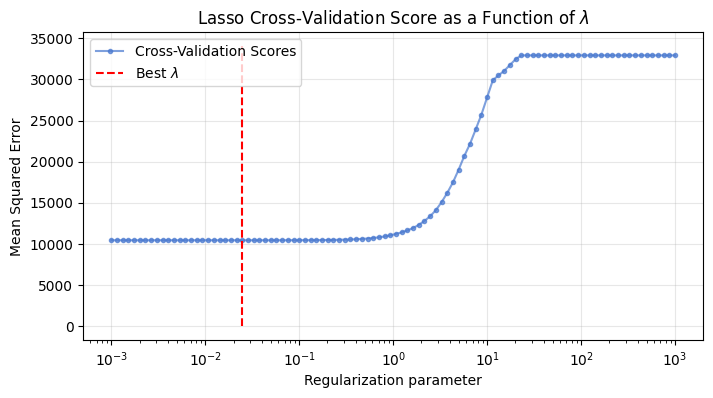

In [30]:
# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the CV MSE for each value of the regularization parameter that was tried
ax.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker="o", markersize=3,
        alpha=0.7, label="Cross-Validation Scores")
# Plot the final chosen regularization parameter
ax.vlines(lasso.alpha_, 0, ax.get_ylim()[1], linestyle="--", color="red", label=r"Best $\lambda$")

# Aesthetics
ax.set_xscale("log")
ax.set_xlabel("Regularization parameter")
ax.set_ylabel("Mean Squared Error")
ax.set_title(r"Lasso Cross-Validation Score as a Function of $\lambda$")
ax.grid(alpha=0.3)
ax.legend()

print(f"Best regularization parameter: {lasso.alpha_:.2f}")


#### ➡️ ✏️ Task 4: Ridge regression

**Note**: There exists `RidgeCV`, but it cannot be used to plot the values of $\lambda$ (or $\alpha$) and the matching cross-validation scores in the same way as with Lasso. You can, however, use the `Ridge` object and perform cross-validation yourself, like we did for the polynomial regression above. Go ahead and try it out! First import the Ridge object.

In [39]:
# ➡️ ✏️ Your code here

In [32]:
# SOLUTION
from sklearn.linear_model import Ridge

# Create the 5-fold cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=72)

# Initialize the list of scores (MSEs, one for each Ridge model)
ridge_scores = []

# Loop over the degrees of the polynomial
for alpha in alphas:
    
    ridge_model = Ridge(alpha=alpha)

    # Compute the cross-validation score and the mean squared error as the scoring function
    cv_score = cross_val_score( ridge_model, X_train, y_train, 
                               cv=cv, scoring="neg_mean_squared_error")
    
    # Append the mean of the cross-validation scores to the list of scores
    ridge_scores.append(-np.mean(cv_score)) # Notice the minus sign, because the MSE is negative

best_alpha_ridge = alphas[np.argmin( ridge_scores)]
best_score_ridge = np.min( ridge_scores)

np.float64(2.848035868435802)

np.float64(10441.602475391754)

Best regularization parameter: 2.85


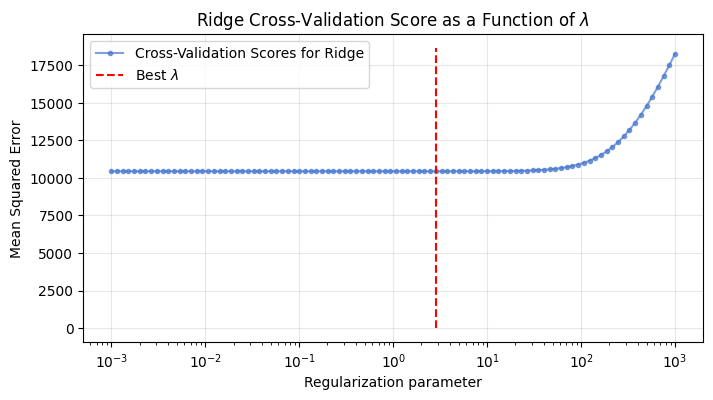

In [33]:
# SOLUTION (continued)
display(best_alpha_ridge)
display(best_score_ridge)

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the CV MSE for each value of the regularization parameter that was tried
ax.plot(alphas, ridge_scores, marker="o", markersize=3,
        alpha=0.7, label="Cross-Validation Scores for Ridge")
# Plot the final chosen regularization parameter
ax.vlines(best_alpha_ridge, 0, ax.get_ylim()[1], linestyle="--", color="red", label=r"Best $\lambda$")

# Aesthetics
ax.set_xscale("log")
ax.set_xlabel("Regularization parameter")
ax.set_ylabel("Mean Squared Error")
ax.set_title(r"Ridge Cross-Validation Score as a Function of $\lambda$")
ax.grid(alpha=0.3)
ax.legend()

print(f"Best regularization parameter: {best_alpha_ridge:.2f}")


#### ➡️ ✏️ Task 5

Write your own code to compare the predictions of the three models we have built so far. Which model performs the best?

In [34]:
# ➡️ ✏️ Your code here

In [35]:
# We already have the best model for LASSO, but still need to get it for ridge
mse_lasso_test = np.min(lasso.mse_path_.mean(axis=1))
mse_lasso_test, mse_test_linreg, best_score_ridge

(np.float64(10441.147906884897),
 np.float64(24055.252122202703),
 np.float64(10441.602475391754))

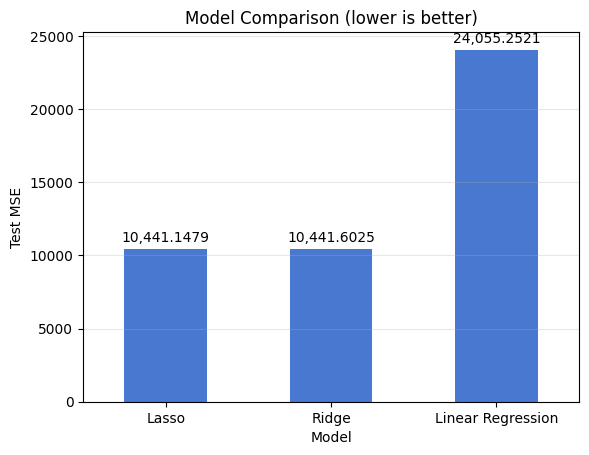

In [36]:
results = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Lasso", "Ridge"],
        "Test MSE": [mse_test_linreg, mse_lasso_test, best_score_ridge],
    }
).set_index("Model").sort_values("Test MSE")



# 2) Bar chart with value labels
ax = results.plot(kind="bar", legend=False, rot=0)
ax.set_ylabel("Test MSE")
ax.set_title("Model Comparison (lower is better)")
ax.grid(axis="y", alpha=0.3)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:,.4f}", (p.get_x() + p.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom")

# Here, for a change, you see a bar plot created in a coding style that's a little different
# from what we have done so far. Just to make you aware that there are many ways to create plots.
# Plot returns Matplotlib Axes. Bars are Rectangle "patches" stored in ax.patches.
# We loop over ax.patches to read each bar’s height (the MSE) and place a label at its center-top.
# get_x()/get_width() give the bar’s horizontal position; get_height() is the value.
# ax.annotate(..., xytext=(0,3), textcoords="offset points") nudges the text a few points above the bar edge.
